In [1]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

In [2]:
from locallib.picarrodb import *
from locallib.query import *
import pandas as pd

EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully
EU1_PROD_Conn created successfully
EU2_PROD_Conn created successfully


In [3]:
a = get_users(customer_name = 'Italgas', user_table = '#TempUser')
b = get_surveys(user_table = '#TempUser', survey_table = '#TempSurvey', start_date = '2026-01-18', end_date = '2026-03-01')
b.set_child(Query(
    query = (
        "SELECT "
        "COUNT(P.Id) AS PeakCount, "
        "P.SurveyId, "
        "SQA.AverageFlowRate "
        "INTO #TempPeak "
        "FROM Peak P "
        "LEFT JOIN SurveyQACheck SQA ON P.SurveyId = SQA.SurveyId "
        "WHERE P.SurveyId IN (SELECT SurveyId FROM #TempSurvey) "
   
        "GROUP BY P.SurveyId, SQA.AverageFlowRate"
    )
))
a.set_child(b)
data = a.execute(EU2_Conn, table_return = ['#TempPeak', '#TempSurvey'])

In [4]:
peak_survey = pd.merge(data['#TempSurvey'][['SurveyId', 'SurveyorUnit','RawDurationMinutes','StartDateTime','EndDateTime']], data['#TempPeak'][['PeakCount', 'SurveyId', 'AverageFlowRate']], on = 'SurveyId', how = 'left')
peak_survey['AverageFlowRate'] = peak_survey['AverageFlowRate'].astype(float)
peak_survey = peak_survey.dropna(subset=['AverageFlowRate'])
peak_survey['PeakMinutes'] = peak_survey['PeakCount'] / peak_survey['RawDurationMinutes']

In [5]:
peak_survey[peak_survey['SurveyorUnit'].astype(str).str.contains('#45')]

,SurveyId,SurveyorUnit,RawDurationMinutes,StartDateTime,EndDateTime,PeakCount,AverageFlowRate,PeakMinutes
3763,72C7E1B1-186A-1129-91FB-3A1EEC983666,Car#45 2i Rete Jeep Renegade GX222TT,81,2026-01-20 08:00:49.423,2026-01-20 09:21:39.257,22.0,4.159385,0.271605
3769,D5F593F6-43F7-43C0-FDE4-3A1EEFA968F0,Car#45 2i Rete Jeep Renegade GX222TT,194,2026-01-20 22:18:16.070,2026-01-21 01:32:07.740,120.0,4.061592,0.618557
3790,F7A89F33-11DF-AB86-8FF2-3A1EF1C9619A,Car#45 2i Rete Jeep Renegade GX222TT,74,2026-01-21 08:12:37.217,2026-01-21 09:26:24.740,37.0,4.100069,0.500000
3827,FFE60B10-32A2-19A3-9727-3A1EFA6854B9,Car#45 2i Rete Jeep Renegade GX222TT,39,2026-01-23 00:22:59.540,2026-01-23 01:01:11.507,30.0,3.877000,0.769231
3898,9A170469-B733-2D9E-1930-3A1F10B47618,Car#45 2i Rete Jeep Renegade GX222TT,228,2026-01-27 08:18:00.143,2026-01-27 12:06:35.170,106.0,3.912049,0.464912
...,...,...,...,...,...,...,...,...
7386,E83FF9BF-662A-58E6-244D-3A1FB8A27CBE,Car#45 2i Rete Jeep Renegade GX222TT,56,2026-02-28 22:54:21.863,2026-02-28 23:50:54.437,9.0,3.775598,0.160714
7399,0DF39178-3ECD-3A2D-4CDD-3A1FB2BCB9B9,Car#45 2i Rete Jeep Renegade GX222TT,93,2026-02-27 19:25:18.503,2026-02-27 20:58:24.287,35.0,3.985042,0.376344
7424,08C3119D-8627-4D5A-4A11-3A1FB812ABA4,Car#45 2i Rete Jeep Renegade GX222TT,16,2026-02-28 20:17:17.057,2026-02-28 20:33:20.503,15.0,3.905462,0.937500
7437,B130EF23-D654-9624-2C89-3A1FB27F2245,Car#45 2i Rete Jeep Renegade GX222TT,66,2026-02-27 18:18:02.990,2026-02-27 19:24:03.093,41.0,3.991306,0.621212


In [11]:
peak_survey = peak_survey.sort_values(['SurveyorUnit', 'StartDateTime'])
peak_survey = peak_survey[peak_survey['AverageFlowRate'] > 0]

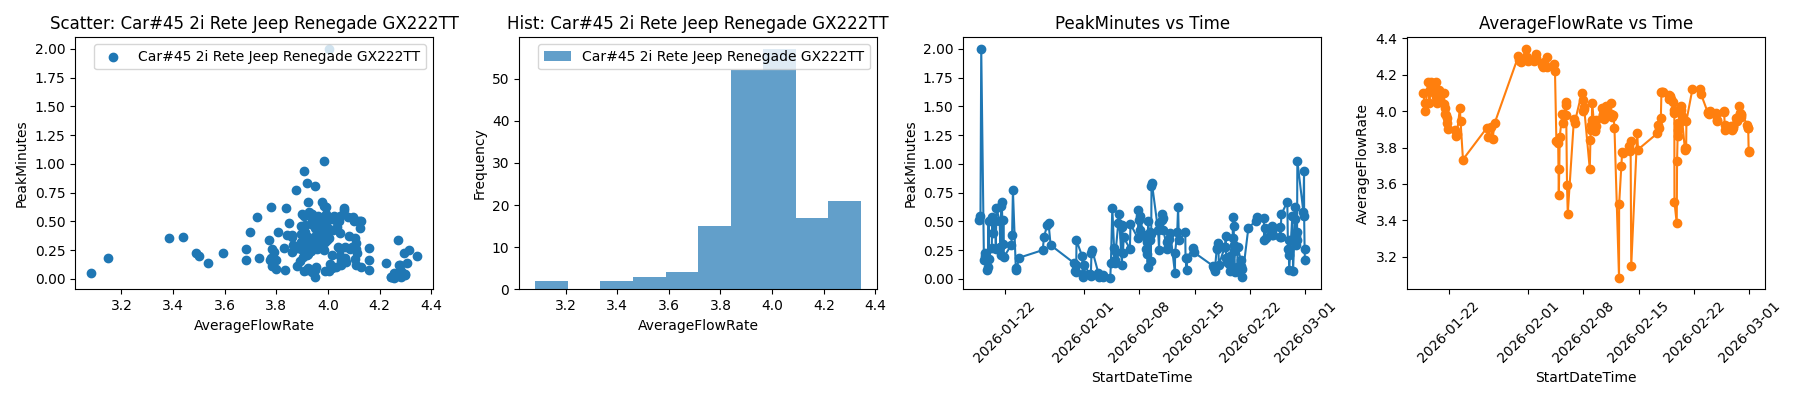

In [12]:
import matplotlib.pyplot as plt

for surveyor_unit in peak_survey.loc[peak_survey['SurveyorUnit'].astype(str).str.contains('#45'), 'SurveyorUnit'].unique():
    subset = peak_survey[peak_survey['SurveyorUnit'] == surveyor_unit].sort_values('StartDateTime')
    
    # Since some subplots were deleted, change shape (now 1 row, 4 columns)
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))

    # 1. Scatter: AverageFlowRate vs PeakMinutes
    axs[0].scatter(
        subset['AverageFlowRate'],
        subset['PeakMinutes'],
        label=surveyor_unit
    )
    axs[0].set_title(f"Scatter: {surveyor_unit}")
    axs[0].set_xlabel('AverageFlowRate')
    axs[0].set_ylabel('PeakMinutes')
    axs[0].legend()

    # 2. Histogram of AverageFlowRate
    axs[1].hist(subset['AverageFlowRate'], label=surveyor_unit, alpha=0.7)
    axs[1].set_title(f"Hist: {surveyor_unit}")
    axs[1].set_xlabel('AverageFlowRate')
    axs[1].set_ylabel('Frequency')
    axs[1].legend()

    # 3. Time series: PeakMinutes over time
    axs[2].plot(subset['StartDateTime'], subset['PeakMinutes'], marker='o')
    axs[2].set_xlabel('StartDateTime')
    axs[2].set_ylabel('PeakMinutes')
    axs[2].set_title(f"PeakMinutes vs Time")
    axs[2].tick_params(axis='x', rotation=45)
    
    # 4. Time series: AverageFlowRate over time
    axs[3].plot(subset['StartDateTime'], subset['AverageFlowRate'], marker='o', color='tab:orange')
    axs[3].set_xlabel('StartDateTime')
    axs[3].set_ylabel('AverageFlowRate')
    axs[3].set_title(f"AverageFlowRate vs Time")
    axs[3].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


In [ ]:
peak_survey.loc[peak_survey['SurveyorUnit'].astype(str).str.contains('#45'), 'SurveyorUnit'].unique()


array(['Car#45 2i Rete Jeep Renegade GX222TT'], dtype=object)

/tmp/ipykernel_34583/2719439262.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


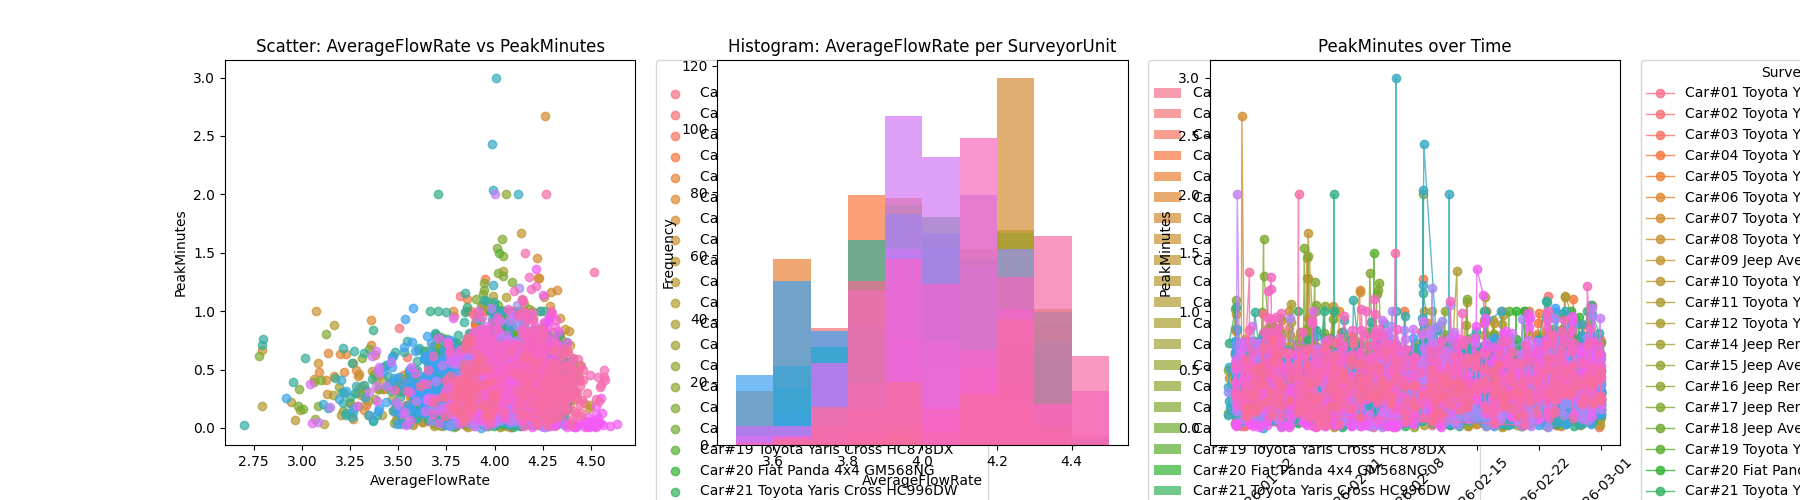

In [14]:
import matplotlib.pyplot as plt

# Assign a color to each unique SurveyorUnit
import seaborn as sns
color_palette = sns.color_palette("husl", len(peak_survey['SurveyorUnit'].unique()))
surveyor_units = peak_survey['SurveyorUnit'].unique()
color_map = dict(zip(surveyor_units, color_palette))

import numpy as np

# Create three plots: scatter, histogram, and time series
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter: AverageFlowRate vs PeakMinutes for all SurveyorUnits
for surveyor_unit in surveyor_units:
    subset = peak_survey[peak_survey['SurveyorUnit'] == surveyor_unit]
    ax1.scatter(
        subset['AverageFlowRate'],
        subset['PeakMinutes'],
        color=color_map[surveyor_unit],
        label=surveyor_unit,
        alpha=0.7
    )
ax1.set_xlabel('AverageFlowRate')
ax1.set_ylabel('PeakMinutes')
ax1.set_title('Scatter: AverageFlowRate vs PeakMinutes')
ax1.legend(title='SurveyorUnit', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# 2. Overlaid histogram for AverageFlowRate for all SurveyorUnits
bins = np.arange(3.5, 4.5 + 0.01, 0.1)  # step size of 0.1 (adjust as needed)
for surveyor_unit in surveyor_units:
    subset = peak_survey[peak_survey['SurveyorUnit'] == surveyor_unit]
    ax2.hist(
        subset['AverageFlowRate'].astype(float),
        bins=bins,
        alpha=0.7,
        label=surveyor_unit,
        color=color_map[surveyor_unit]
    )
ax2.set_title("Histogram: AverageFlowRate per SurveyorUnit")
ax2.set_xlabel('AverageFlowRate')
ax2.set_ylabel('Frequency')
ax2.legend(title='SurveyorUnit', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# 3. Time plot: PeakMinutes over StartDateTime for all SurveyorUnits
for surveyor_unit in surveyor_units:
    subset = peak_survey[peak_survey['SurveyorUnit'] == surveyor_unit].sort_values('StartDateTime')
    ax3.plot(
        subset['StartDateTime'],
        subset['PeakMinutes'],
        marker='o',
        label=surveyor_unit,
        color=color_map[surveyor_unit],
        alpha=0.8,
        linewidth=1
    )
ax3.set_xlabel('StartDateTime')
ax3.set_ylabel('PeakMinutes')
ax3.set_title('PeakMinutes over Time')
ax3.legend(title='SurveyorUnit', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [15]:
peak_survey

,SurveyId,SurveyorUnit,RawDurationMinutes,StartDateTime,EndDateTime,PeakCount,AverageFlowRate,PeakMinutes
274,5651742C-786D-5704-87B1-3A1EE987F33B,Car#01 Toyota Yaris Cross HC999DW,99,2026-01-19 17:44:11.190,2026-01-19 19:23:40.657,28.0,4.081454,0.282828
286,228A6C2A-C00F-D430-F7AA-3A1EE9E3C4B8,Car#01 Toyota Yaris Cross HC999DW,33,2026-01-19 19:24:10.980,2026-01-19 19:57:45.567,3.0,4.262442,0.090909
294,BBFE4C79-F3BD-0A6A-208E-3A1EEA12EA86,Car#01 Toyota Yaris Cross HC999DW,35,2026-01-19 20:15:49.797,2026-01-19 20:50:42.767,1.0,4.308689,0.028571
36,7F3B8541-14F1-F17F-D8B6-3A1EEA335237,Car#01 Toyota Yaris Cross HC999DW,59,2026-01-19 20:51:04.333,2026-01-19 21:50:17.247,2.0,4.264233,0.033898
50,EFC4C433-0BE3-995E-D058-3A1EEA7E3C28,Car#01 Toyota Yaris Cross HC999DW,47,2026-01-19 22:12:54.627,2026-01-19 22:59:41.780,1.0,4.313673,0.021277
...,...,...,...,...,...,...,...,...
6601,DF4077C1-2EBB-9245-0486-3A1F881F876C,Car#55 2i Rete Jeep Avenger GW968ZG,10,2026-02-19 12:49:26.450,2026-02-19 12:59:44.177,1.0,3.742733,0.100000
7072,D8625FD0-BF9D-8AFD-3933-3A1FB33B3388,Car#55 2i Rete Jeep Avenger GW968ZG,153,2026-02-27 21:43:21.393,2026-02-28 00:16:53.067,60.0,3.976873,0.392157
6910,C8B4953C-CC54-3441-04A4-3A1FB3C8329D,Car#55 2i Rete Jeep Avenger GW968ZG,128,2026-02-28 00:17:20.193,2026-02-28 02:25:20.560,26.0,3.939336,0.203125
7425,6073F6A9-CC8B-68D4-F4E0-3A1FB81D26FB,Car#55 2i Rete Jeep Avenger GW968ZG,130,2026-02-28 20:28:39.007,2026-02-28 22:38:54.817,36.0,3.999670,0.276923
